In [1]:
import os
from pathlib import Path
import pandas as pd
import numpy as np
import json
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
from sklearn.model_selection import train_test_split
# from CTRLEval.ctrleval import CTRLEval
import nltk
import torch.nn.functional as F
import torch
import copy
from nltk.translate.bleu_score import sentence_bleu
from nltk import word_tokenize
from openai import OpenAI
from dotenv import load_dotenv
load_dotenv()
device = "cuda" if torch.cuda.is_available() else "cpu"

%load_ext autoreload

%autoreload 2

In [2]:
client = OpenAI(
    api_key=os.getenv("CLARIN_API_KEY"),
    base_url="https://services.clarin-pl.eu/api/v1/oapi")


In [11]:
client = OpenAI(
    api_key="EMPTY",
    base_url="http://localhost:8000/v1")

In [13]:
resp = client.chat.completions.create(
    model="google/gemma-4-31B-it",
    messages=[
        {"role": "system", "content": "You are a helpful assistant for evaluating the quality of generated text."},
        {"role": "user", "content": "Evaluate the following text: 'The cat is on the mat.'"}
    ],
    temperature=0.2,
    max_tokens=200,
)

In [14]:
resp

ChatCompletion(id='chatcmpl-b3fee738e6bf45ba', choices=[Choice(finish_reason='length', index=0, logprobs=None, message=ChatCompletionMessage(content=None, refusal=None, role='assistant', annotations=None, audio=None, function_call=None, tool_calls=[], reasoning='*   Input text: "The cat is on the mat."\n    *   Task: Evaluate the quality of the generated text.\n    *   Role: Helpful assistant for evaluating text quality.\n\n    *   Grammar: Correct.\n    *   Syntax: Simple subject-verb-prepositional phrase structure.\n    *   Clarity: Extremely clear.\n    *   Conciseness: Very concise.\n    *   Meaning: Literal and straightforward.\n    *   Context: Lacks context (it\'s a standalone sentence), but as a sentence, it\'s a classic example of a basic English sentence.\n\n    *   *Grammatical Correctness:* 10/10.\n    *   *Clarity:* 10/10.\n    *   *Complexity:* Very low (Basic).\n    *   *Engagement/Creativity:* Low (Generic).\n\n    *   *Positive:* It'), stop_reason=None, token_ids=None)

In [2]:
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt_tab to
[nltk_data]     /home/mindflayer/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

In [4]:
classifications = pd.read_csv('../data/classifications.csv')
print(classifications.shape)
classifications.head()

(17480, 11)


,paperId,abstract,summary,node_id,relationships,scores,reasoning,input_tokens,output_tokens,reasoning_tokens,total_tokens
0,170d56d693333ea6fff09a59f9dd43594d4a94dc,"Nowadays, the complex manufacturing processes ...",OBJECTIVE: \nAddress the limitations of Marko...,4:a7055092-7933-4d6f-a93a-a08abf5e63aa:19225,"[{""relationship_type"": ""REFERENCES"", ""source_n...","{""sota_chaser"": 0, ""rigorous_skeptic"": 3, ""dat...",The user wants me to classify an article's abs...,3200,2513,0,5713
1,a02797530b9c01e2fde83db8a4f23dbeaa83bbfb,Alzheimer’s disease (AD) is a progressive neur...,OBJECTIVE: Alzheimer’s disease (AD) progressio...,4:a7055092-7933-4d6f-a93a-a08abf5e63aa:2181,"[{""relationship_type"": ""REFERENCES"", ""source_n...","{""data_engineer"": 1, ""efficient_compute"": 0, ""...",The user wants me to classify how well an arti...,3364,3084,0,6448
2,c88d3fa54149652203a799c7d2a3c39071d9477f,Operators handling abnormal situations in safe...,OBJECTIVE: \nExisting safety-critical system ...,4:a7055092-7933-4d6f-a93a-a08abf5e63aa:19218,"[{""relationship_type"": ""REFERENCES"", ""source_n...","{""rigorous_skeptic"": 4, ""sota_chaser"": 1, ""dat...",The user wants me to classify how well a given...,3456,3505,0,6961
3,29ed5ab47631800c922f42ef1ff5165a1df56fc8,While self-training has advanced semi-supervis...,OBJECTIVE: \nSemi-supervised semantic segment...,4:a7055092-7933-4d6f-a93a-a08abf5e63aa:11978,"[{""relationship_type"": ""REFERENCES"", ""source_n...","{""rigorous_skeptic"": 2, ""sota_chaser"": 5, ""dom...",The user wants me to classify how well a given...,3219,3565,0,6784
4,e5c497d44cff4829933525340638dd2937fe6768,We present an abstraction and refinement metho...,OBJECTIVE: \nAddress two critical limitations...,4:a7055092-7933-4d6f-a93a-a08abf5e63aa:20762,"[{""relationship_type"": ""REFERENCES"", ""source_n...","{""domain_expert"": 4, ""data_engineer"": 1, ""rigo...",The user wants to classify how well the provid...,3223,3585,0,6808


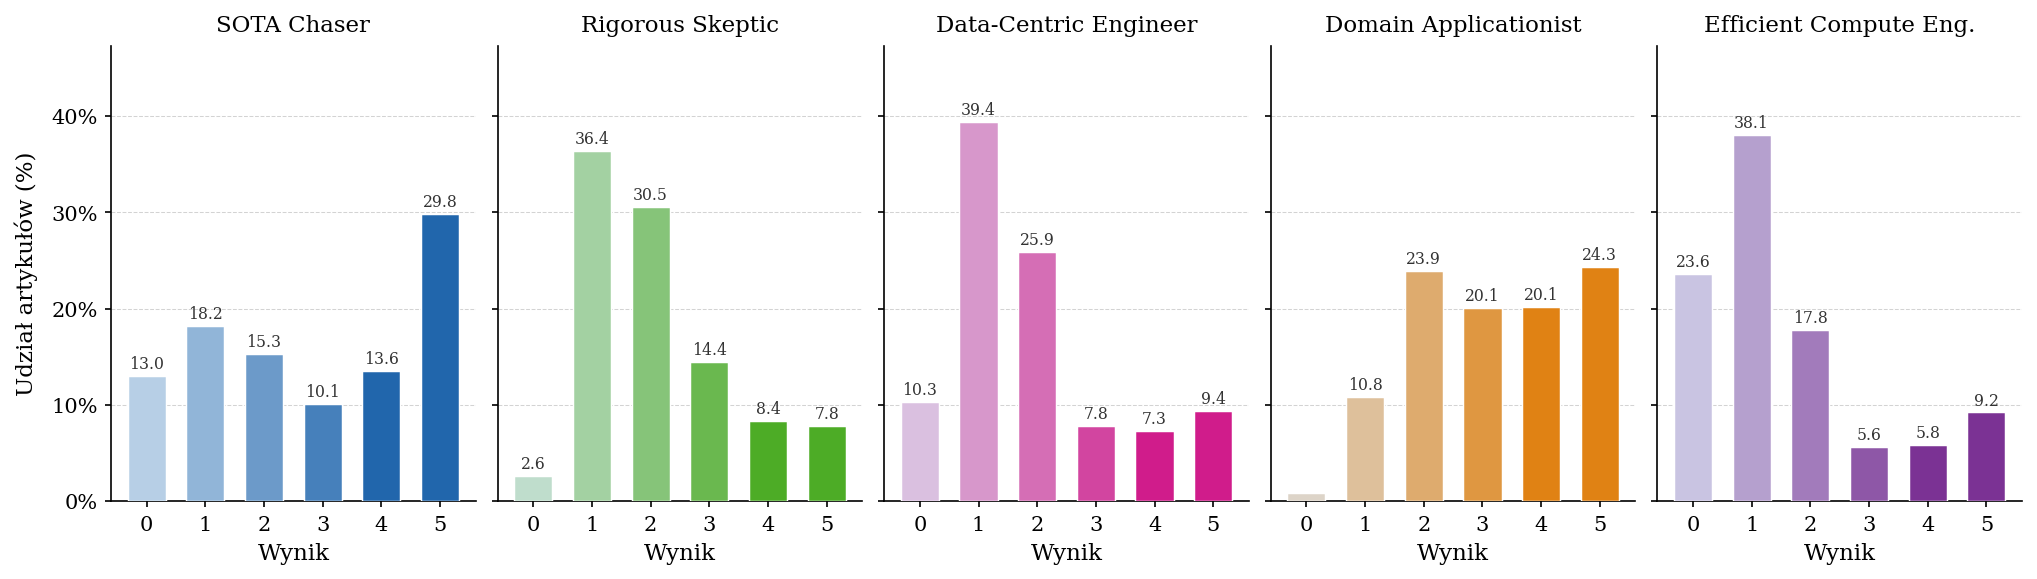

Saved to ../data/classification_distribution.png


In [ ]:

import json
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from matplotlib.colors import LinearSegmentedColormap
import pandas as pd

plt.rcParams.update({
    "text.usetex": False,
    "font.family": "serif",
    "font.serif": ["DejaVu Serif", "Times New Roman", "serif"],
    "font.size": 11,
    "axes.titlesize": 11,
    "axes.labelsize": 11,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "legend.fontsize": 10,
    "figure.dpi": 150,
})

PERSONA_COLS = ["sota_chaser", "rigorous_skeptic", "data_engineer", "domain_expert", "efficient_compute"]
PERSONA_LABELS = {
    "sota_chaser":       "SOTA Chaser",
    "rigorous_skeptic":  "Rigorous Skeptic",
    "data_engineer":     "Data-Centric Engineer",
    "domain_expert":     "Domain Applicationist",
    "efficient_compute": "Efficient Compute Eng.",
}
SCORES = [0, 1, 2, 3, 4, 5]

# --- parse scores ---
scores_df = classifications["scores"].apply(json.loads)
scores_df = pd.json_normalize(scores_df)[PERSONA_COLS]

# compute percentage distribution per persona
dist = {}
for col in PERSONA_COLS:
    counts = scores_df[col].dropna().value_counts().sort_index()
    pct = counts / counts.sum() * 100
    dist[col] = pct.reindex(SCORES, fill_value=0.0)

# --- colour palette ---
palette = ["#2166ac", "#4dac26", "#d01c8b", "#e08214", "#7b3294"]

fig, axes = plt.subplots(1, 5, figsize=(14, 4.6), sharey=True)
fig.subplots_adjust(wspace=0.06, left=0.07, right=0.98, top=0.80, bottom=0.14)

bar_width = 0.65
x = np.arange(len(SCORES))
y_max = max(d.max() for d in dist.values()) * 1.20

for ax, col, base_color in zip(axes, PERSONA_COLS, palette):
    vals = dist[col].values

    cmap = LinearSegmentedColormap.from_list("mono", ["#dce9f5", base_color], N=6)
    bar_colors = cmap(np.linspace(0.25, 1.0, 6))

    bars = ax.bar(x, vals, width=bar_width, color=bar_colors,
                  edgecolor="white", linewidth=0.7, zorder=3)

    for bar, v in zip(bars, vals):
        if v >= 1.0:
            ax.text(
                bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 0.4,
                f"{v:.1f}",
                ha="center", va="bottom",
                fontsize=7.5, color="#333333",
            )

    ax.set_xticks(x)
    ax.set_xticklabels([str(s) for s in SCORES])
    ax.set_xlabel("Wynik", labelpad=4)
    ax.set_title(PERSONA_LABELS[col], pad=7)
    ax.yaxis.set_major_formatter(mticker.FormatStrFormatter("%.0f%%"))
    ax.set_ylim(0, y_max)
    ax.grid(axis="y", linestyle="--", linewidth=0.5, alpha=0.55, zorder=0)
    ax.spines[["top", "right"]].set_visible(False)
    ax.tick_params(axis="both", which="both", length=3)

axes[0].set_ylabel("Udział artykułów (%)", labelpad=6)

# fig.suptitle("Rozkład wyników klasyfikacji per persona", fontsize=13, y=0.96)

output_path = "../data/classification_distribution.png"
plt.savefig(output_path, format="png", bbox_inches="tight")
plt.show()
print(f"Saved to {output_path}")


Saved: ../data/neighbourhood_balance_bar.png


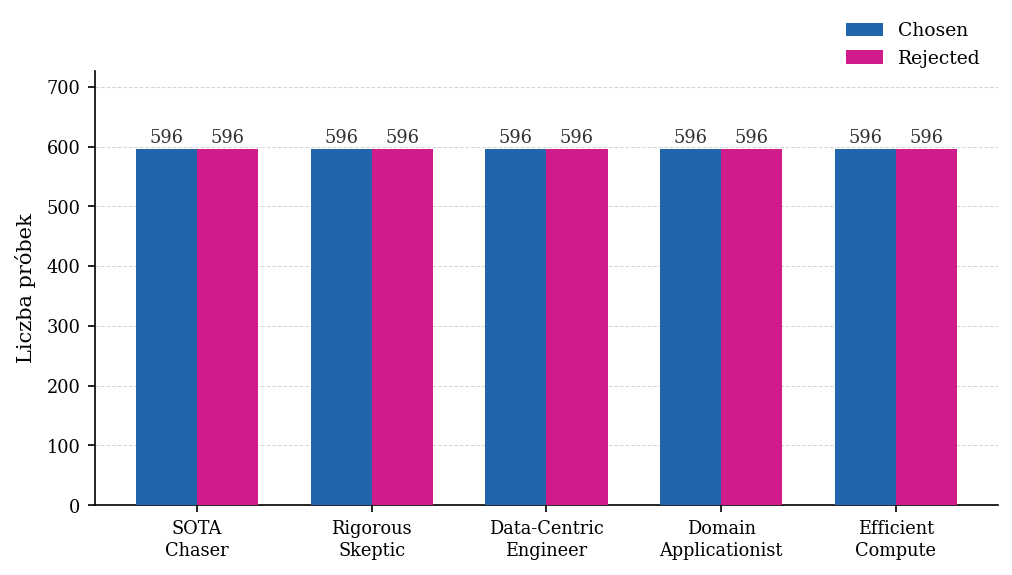

Saved: ../data/neighbourhood_balance_heatmap.png


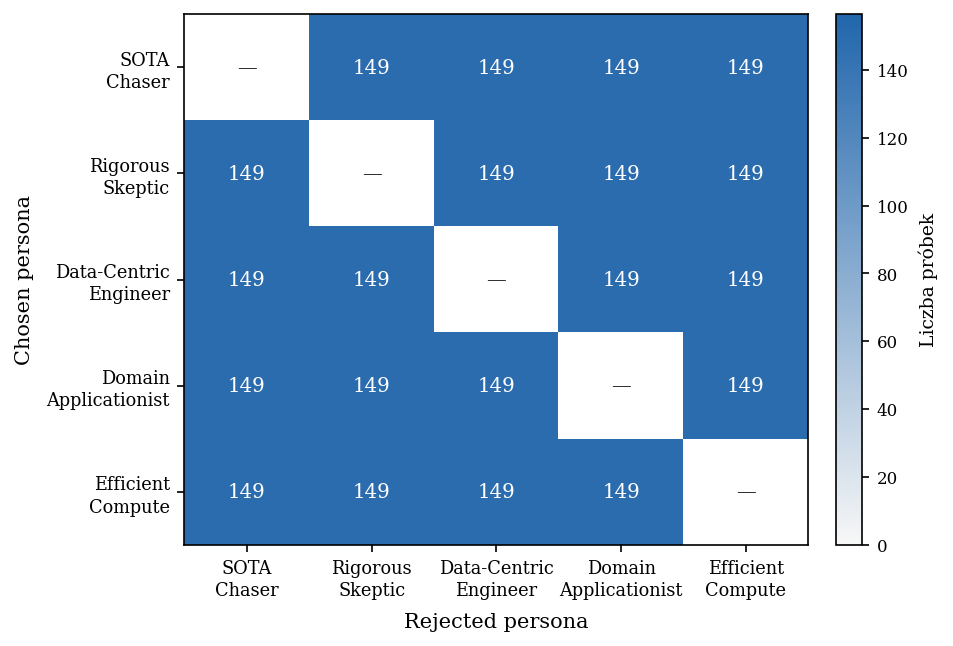

In [24]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from matplotlib.colors import LinearSegmentedColormap

nb = pd.read_csv('../data/neighbourhood_balanced.csv')

PERSONA_ORDER = ["sota_chaser", "rigorous_skeptic", "data_engineer", "domain_expert", "efficient_compute"]
PERSONA_LABELS_SHORT = {
    "sota_chaser":       "SOTA\nChaser",
    "rigorous_skeptic":  "Rigorous\nSkeptic",
    "data_engineer":     "Data-Centric\nEngineer",
    "domain_expert":     "Domain\nApplicationist",
    "efficient_compute": "Efficient\nCompute",
}
TICK_LABELS = [PERSONA_LABELS_SHORT[p] for p in PERSONA_ORDER]

chosen_counts   = nb["chosen_persona"].value_counts().reindex(PERSONA_ORDER, fill_value=0)
rejected_counts = nb["rejected_persona"].value_counts().reindex(PERSONA_ORDER, fill_value=0)

pair_matrix = (
    nb.groupby(["chosen_persona", "rejected_persona"])
      .size()
      .unstack(fill_value=0)
      .reindex(index=PERSONA_ORDER, columns=PERSONA_ORDER, fill_value=0)
)

plt.rcParams.update({
    "text.usetex": False,
    "font.family": "serif",
    "font.serif":  ["DejaVu Serif", "Times New Roman", "serif"],
    "font.size":   11,
    "axes.titlesize": 11,
    "axes.labelsize": 10,
    "xtick.labelsize": 8.5,
    "ytick.labelsize": 8.5,
    "figure.dpi":  150,
})

color_chosen   = "#2166ac"
color_rejected = "#d01c8b"
cmap_heat = LinearSegmentedColormap.from_list("heat", ["#f7f7f7", "#2166ac"])

# ── Figure 1: grouped bar chart ───────────────────────────────────────────────
fig1, ax_bar = plt.subplots(figsize=(7, 4.6))
fig1.subplots_adjust(left=0.11, right=0.97, top=0.85, bottom=0.22)

x = np.arange(len(PERSONA_ORDER))
w = 0.35

bars_c = ax_bar.bar(x - w/2, chosen_counts,   width=w, color=color_chosen,   label="Chosen",   zorder=3)
bars_r = ax_bar.bar(x + w/2, rejected_counts, width=w, color=color_rejected, label="Rejected", zorder=3)

for bar in list(bars_c) + list(bars_r):
    ax_bar.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 4,
        str(int(bar.get_height())),
        ha="center", va="bottom", fontsize=8.5, color="#333333",
    )

ax_bar.set_xticks(x)
ax_bar.set_xticklabels(TICK_LABELS, linespacing=1.3)
ax_bar.set_ylabel("Liczba próbek", labelpad=5)
# ax_bar.set_title("Rozkład etykiet chosen / rejected per persona", pad=8)
ax_bar.set_ylim(0, max(chosen_counts.max(), rejected_counts.max()) * 1.22)
ax_bar.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"{int(v):,}"))
ax_bar.grid(axis="y", linestyle="--", linewidth=0.5, alpha=0.5, zorder=0)
ax_bar.spines[["top", "right"]].set_visible(False)
ax_bar.legend(frameon=False, loc="upper right", fontsize=9, bbox_to_anchor=(1.0, 1.15))

for fmt in ("png",):
    path = f"../data/neighbourhood_balance_bar.{fmt}"
    fig1.savefig(path, format=fmt, bbox_inches="tight", dpi=200)
    print(f"Saved: {path}")

plt.show()

# ── Figure 2: pair heatmap ────────────────────────────────────────────────────
fig2, ax_heat = plt.subplots(figsize=(6.5, 5.2))
fig2.subplots_adjust(left=0.18, right=0.88, top=0.90, bottom=0.22)

mat = pair_matrix.values.astype(float)
mat_display = mat.copy()
mat_display[mat_display == 0] = np.nan

im = ax_heat.imshow(mat_display, cmap=cmap_heat,
                    vmin=0, vmax=mat[mat > 0].max() * 1.05, aspect="auto")

for i in range(len(PERSONA_ORDER)):
    for j in range(len(PERSONA_ORDER)):
        val = pair_matrix.values[i, j]
        text = str(val) if val > 0 else "—"
        color_txt = "white" if val > mat[mat > 0].max() * 0.55 else "#333333"
        ax_heat.text(j, i, text, ha="center", va="center", fontsize=9.5, color=color_txt)

ax_heat.set_xticks(range(len(PERSONA_ORDER)))
ax_heat.set_yticks(range(len(PERSONA_ORDER)))
ax_heat.set_xticklabels(TICK_LABELS, linespacing=1.3)
ax_heat.set_yticklabels(TICK_LABELS, linespacing=1.3)
ax_heat.set_xlabel("Rejected persona", labelpad=6)
ax_heat.set_ylabel("Chosen persona", labelpad=6)
# ax_heat.set_title("Liczba par (chosen × rejected)", pad=8)

cbar = fig2.colorbar(im, ax=ax_heat, fraction=0.046, pad=0.04)
cbar.ax.tick_params(labelsize=8)
cbar.set_label("Liczba próbek", fontsize=9, labelpad=5)

for fmt in ("png",):
    path = f"../data/neighbourhood_balance_heatmap.{fmt}"
    fig2.savefig(path, format=fmt, bbox_inches="tight", dpi=200)
    print(f"Saved: {path}")

plt.show()


## d Cohena
### Llama3.2-3B

In [2]:
import pandas as pd
import numpy as np
from transformers import AutoTokenizer
from dotenv import load_dotenv
from huggingface_hub import login

load_dotenv()

login(token=os.environ.get("HF_TOKEN"))

# ── Load data ─────────────────────────────────────────────────────────────────
dpo = pd.read_csv('../hypotheses/final_3/clean/dpo.csv')
print(f"Loaded {len(dpo)} rows")

# ── Tokenizer ─────────────────────────────────────────────────────────────────
tokenizer = AutoTokenizer.from_pretrained(
    # "Qwen/Qwen3-1.7B",
    "meta-llama/Llama-3.2-3B-Instruct",
    trust_remote_code=True,
)

def token_lengths(texts: pd.Series) -> np.ndarray:
    return np.array([
        len(tokenizer.encode(t, add_special_tokens=False))
        for t in texts
    ])

# ── Compute lengths ───────────────────────────────────────────────────────────
print("Tokenizing... (this may take a moment)")
len_reasoning_chosen   = token_lengths(dpo["reasoning_chosen"])
len_reasoning_rejected = token_lengths(dpo["reasoning_rejected"])
len_chosen             = token_lengths(dpo["chosen"])
len_rejected           = token_lengths(dpo["rejected"])
len_full_chosen        = token_lengths(dpo["reasoning_chosen"] + " " + dpo["chosen"])
len_full_rejected      = token_lengths(dpo["reasoning_rejected"] + " " + dpo["rejected"])
print("Done.")

# ── Cohen's d ────────────────────────────────────────────────────────────────
def cohens_d(a: np.ndarray, b: np.ndarray) -> float:
    n1, n2 = len(a), len(b)
    pooled_std = np.sqrt(
        ((n1 - 1) * a.std(ddof=1)**2 + (n2 - 1) * b.std(ddof=1)**2) / (n1 + n2 - 2)
    )
    return (a.mean() - b.mean()) / pooled_std

comparisons = {
    "reasoning_chosen vs reasoning_rejected": (len_reasoning_chosen, len_reasoning_rejected),
    "chosen vs rejected":                     (len_chosen,           len_rejected),
    "full_chosen vs full_rejected":            (len_full_chosen,      len_full_rejected),
}

# ── Results table ─────────────────────────────────────────────────────────────
rows = []
for name, (a, b) in comparisons.items():
    rows.append({
        "comparison": name,
        "mean_A":     round(a.mean(), 1),
        "std_A":      round(a.std(ddof=1), 1),
        "mean_B":     round(b.mean(), 1),
        "std_B":      round(b.std(ddof=1), 1),
        "diff":       round(a.mean() - b.mean(), 1),
        "cohens_d":   round(cohens_d(a, b), 4),
    })

stats = pd.DataFrame(rows)
print(stats.to_string(index=False))
stats


Note: Environment variable`HF_TOKEN` is set and is the current active token independently from the token you've just configured.


Loaded 492 rows
Tokenizing... (this may take a moment)
Done.
                            comparison  mean_A  std_A  mean_B  std_B  diff  cohens_d
reasoning_chosen vs reasoning_rejected   635.2  296.8   583.7  292.8  51.6    0.1750
                    chosen vs rejected   151.6   15.8   149.8   15.9   1.8    0.1120
          full_chosen vs full_rejected   786.7  295.5   733.3  293.3  53.3    0.1812


,comparison,mean_A,std_A,mean_B,std_B,diff,cohens_d
0,reasoning_chosen vs reasoning_rejected,635.2,296.8,583.7,292.8,51.6,0.1750
1,chosen vs rejected,151.6,15.8,149.8,15.9,1.8,0.1120
2,full_chosen vs full_rejected,786.7,295.5,733.3,293.3,53.3,0.1812


## d Cohena 
### Qwen3-4B

In [3]:
import pandas as pd
import numpy as np
from transformers import AutoTokenizer
from dotenv import load_dotenv
from huggingface_hub import login

load_dotenv()

login(token=os.environ.get("HF_TOKEN"))

# ── Load data ─────────────────────────────────────────────────────────────────
dpo = pd.read_csv('../hypotheses/final_3/clean/dpo.csv')
print(f"Loaded {len(dpo)} rows")

# ── Tokenizer ─────────────────────────────────────────────────────────────────
tokenizer = AutoTokenizer.from_pretrained(
    "Qwen/Qwen3-4B",
    # "meta-llama/Llama-3.2-3B-Instruct",
    trust_remote_code=True,
)

def token_lengths(texts: pd.Series) -> np.ndarray:
    return np.array([
        len(tokenizer.encode(t, add_special_tokens=False))
        for t in texts
    ])

# ── Compute lengths ───────────────────────────────────────────────────────────
print("Tokenizing... (this may take a moment)")
len_reasoning_chosen   = token_lengths(dpo["reasoning_chosen"])
len_reasoning_rejected = token_lengths(dpo["reasoning_rejected"])
len_chosen             = token_lengths(dpo["chosen"])
len_rejected           = token_lengths(dpo["rejected"])
len_full_chosen        = token_lengths(dpo["reasoning_chosen"] + " " + dpo["chosen"])
len_full_rejected      = token_lengths(dpo["reasoning_rejected"] + " " + dpo["rejected"])
print("Done.")

# ── Cohen's d ────────────────────────────────────────────────────────────────
def cohens_d(a: np.ndarray, b: np.ndarray) -> float:
    n1, n2 = len(a), len(b)
    pooled_std = np.sqrt(
        ((n1 - 1) * a.std(ddof=1)**2 + (n2 - 1) * b.std(ddof=1)**2) / (n1 + n2 - 2)
    )
    return (a.mean() - b.mean()) / pooled_std

comparisons = {
    "reasoning_chosen vs reasoning_rejected": (len_reasoning_chosen, len_reasoning_rejected),
    "chosen vs rejected":                     (len_chosen,           len_rejected),
    "full_chosen vs full_rejected":            (len_full_chosen,      len_full_rejected),
}

# ── Results table ─────────────────────────────────────────────────────────────
rows = []
for name, (a, b) in comparisons.items():
    rows.append({
        "comparison": name,
        "mean_A":     round(a.mean(), 1),
        "std_A":      round(a.std(ddof=1), 1),
        "mean_B":     round(b.mean(), 1),
        "std_B":      round(b.std(ddof=1), 1),
        "diff":       round(a.mean() - b.mean(), 1),
        "cohens_d":   round(cohens_d(a, b), 4),
    })

stats = pd.DataFrame(rows)
print(stats.to_string(index=False))
stats


Note: Environment variable`HF_TOKEN` is set and is the current active token independently from the token you've just configured.


Loaded 492 rows


tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json:   0%|          | 0.00/11.4M [00:00<?, ?B/s]

Tokenizing... (this may take a moment)
Done.
                            comparison  mean_A  std_A  mean_B  std_B  diff  cohens_d
reasoning_chosen vs reasoning_rejected   652.8  310.4   598.7  305.1  54.1    0.1758
                    chosen vs rejected   153.3   16.1   151.2   16.7   2.0    0.1247
          full_chosen vs full_rejected   805.9  309.1   749.8  305.8  56.1    0.1826


,comparison,mean_A,std_A,mean_B,std_B,diff,cohens_d
0,reasoning_chosen vs reasoning_rejected,652.8,310.4,598.7,305.1,54.1,0.1758
1,chosen vs rejected,153.3,16.1,151.2,16.7,2.0,0.1247
2,full_chosen vs full_rejected,805.9,309.1,749.8,305.8,56.1,0.1826


In [4]:
import numpy as np

# Funkcja obliczająca d Cohena dla prób zależnych (sparowanych)
def cohens_d_paired(a: np.ndarray, b: np.ndarray) -> float:
    # Obliczamy wektor różnic wewnątrz par
    diffs = a - b
    # d_z = średnia z różnic podzielona przez odchylenie standardowe z różnic
    return diffs.mean() / diffs.std(ddof=1)

# Zakładamy, że len_* to jednowymiarowe tablice numpy (np.ndarray) o jednakowych długościach.
comparisons = {
    "reasoning_chosen vs reasoning_rejected": (len_reasoning_chosen, len_reasoning_rejected),
    "chosen vs rejected":                     (len_chosen,           len_rejected),
    "full_chosen vs full_rejected":           (len_full_chosen,      len_full_rejected),
}

# ── Results table ─────────────────────────────────────────────────────────────
rows = []
for name, (a, b) in comparisons.items():
    # Zapisujemy wektor różnic do zmiennej, aby wyciągnąć statystyki parowe do tabeli
    diffs = a - b
    
    rows.append({
        "comparison": name,
        "mean_A":     round(a.mean(), 1),
        "std_A":      round(a.std(ddof=1), 1),
        "mean_B":     round(b.mean(), 1),
        "std_B":      round(b.std(ddof=1), 1),
        "mean_diff":  round(diffs.mean(), 1),     # Średnia różnica wewnątrz par
        "std_diff":   round(diffs.std(ddof=1), 1), # Odchylenie standardowe różnic
        "cohens_d_z": round(cohens_d_paired(a, b), 4),
    })

# Wyświetlanie wyników w konsoli
for row in rows:
    print(f"Porównanie: {row['comparison']}")
    print(f"Średnia A: {row['mean_A']} (std: {row['std_A']}) | Średnia B: {row['mean_B']} (std: {row['std_B']})")
    print(f"Średnia różnica par: {row['mean_diff']} (std różnic: {row['std_diff']})")
    print(f"Cohen's d_z: {row['cohens_d_z']}\n")

Porównanie: reasoning_chosen vs reasoning_rejected
Średnia A: 635.2 (std: 296.8) | Średnia B: 583.7 (std: 292.8)
Średnia różnica par: 51.6 (std różnic: 405.8)
Cohen's d_z: 0.1271

Porównanie: chosen vs rejected
Średnia A: 151.6 (std: 15.8) | Średnia B: 149.8 (std: 15.9)
Średnia różnica par: 1.8 (std różnic: 22.3)
Cohen's d_z: 0.0797

Porównanie: full_chosen vs full_rejected
Średnia A: 786.7 (std: 295.5) | Średnia B: 733.3 (std: 293.3)
Średnia różnica par: 53.3 (std różnic: 404.6)
Cohen's d_z: 0.1318



In [3]:
data = pd.read_csv('../hypotheses/hypotheses_Qwen3-32B_cleaned.csv')

data.head()

,prompt_id,user_id,is_answerable,hypothesis_chosen,falsification_criteria,retrieved_context,context_meta,reasoning_chosen,prompt,topic_id,topic_name,hypothesis_rejected,reasoning_rejected,rejected_prompt_id
0,5199,efficient_compute,True,If the depth of a score-based model is increas...,An experiment measuring latency across models ...,E. Scaling to Large Channel Sizes\n\nWe verify...,"[{'chunk_id': 13, 'doc_id': 'bdbc6cc21a4295699...","\nOkay, let's start by understanding the user'...",What are the best neural network architectures...,525,Neural Network Architectures for Score Estimat...,If a DNN architecture with batch normalization...,"\nOkay, let's tackle this. The user is asking ...",525
1,10489,theorist,True,If the second largest eigenvalue λ₂(V) of the ...,An experimental implementation of the CKF with...,"0. To prove this, we need the following propos...","[{'chunk_id': 6, 'doc_id': '277741f823bb3d6a49...","\nOkay, let's tackle this. The user is asking ...",I am interested in a formal analysis of the co...,1148,Networked Kalman Filters for Distributed Audio...,If the communication range parameter in the se...,"\nOkay, let's tackle this. The user is asking ...",1148
2,7845,data_engineer,True,If reward shaping strategies employ preference...,A controlled experiment showing that models tr...,The contributions of this work are threefold: ...,"[{'chunk_id': 1, 'doc_id': '90d8f96e2cd71a50b4...","\nOkay, let's tackle this. The user is a Data-...",Given the inherent noise and bias in human ann...,839,Reinforcement Learning Techniques for Summariz...,"If the reward function $ R(i, a) $ is convex i...","\nOkay, let's tackle this. The user is asking ...",10180
3,3434,interpreter,True,If progressive upsampling strategies in HiFi-G...,An experiment using the same generator archite...,"6. Discussion\n\nArchitecture-wise, the six ge...","[{'chunk_id': 4, 'doc_id': '1ee20991b5b3441bb1...","\nOkay, let's tackle this. The user is an Ethi...",I'm intrigued by the intricate architectures i...,1098,Advanced Convolutional Architectures in HiFi-G...,If dilated convolutions in HiFi-GAN's residual...,"\nOkay, let's tackle this. The user wants a hy...",5772
4,6521,efficient_compute,True,If structured kernel interpolation with grid-b...,An experiment benchmarking KISS-GP against sta...,3.1. From Deterministic to Bayesian\n\nTo deal...,"[{'chunk_id': 2, 'doc_id': '1531701754a1459fa7...","\nOkay, let's tackle this. The user is asking ...",What are the current best practices for reduci...,1851,Deep Gaussian Processes and Hierarchical Laten...,If a layered Gaussian Process architecture emp...,"\nOkay, let's tackle this. The user is asking ...",11187


In [3]:
data[data['user_id'] == 'domain_expert'].first_valid_index()

np.int64(1100)

In [5]:
# grouped = data.groupby('prompt_id')
print(data['topic_id'].unique().shape)

(2339,)


In [130]:
df_sample = data.groupby("user_id", group_keys=False).apply(
    lambda x: x.sample(n=10, random_state=42)
)
df_sample.groupby('user_id').size()

/tmp/ipykernel_16254/3625726860.py:1: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_sample = data.groupby("user_id", group_keys=False).apply(


user_id
data_engineer        10
domain_expert        10
efficient_compute    10
interpreter          10
sota_chaser          10
theorist             10
dtype: int64

## Cosine similarity between personas

In [118]:
from sentence_transformers import SentenceTransformer
from personalization.evaluation.metrics.cosine_similarity import analyze_semantic_similarity, calculate_umap
from personalization.evaluation.visualization.cosine_similarity import plot_similarity_heatmap, plot_intra_inter_comparison, visualize_umap

In [196]:
model = SentenceTransformer('all-MiniLM-L6-v2', device=device)
model.device

device(type='cuda', index=0)

In [197]:
summary_pairs, summary_agg, embeddings = analyze_semantic_similarity(df_sample, model, text_col='hypothesis_chosen', user_col='user_id')

Encoding texts...


Batches:   0%|          | 0/94 [00:00<?, ?it/s]

Computing similarity matrix...
Getting users
Build indices
Get scores
Same user mask
Intra df
Different user mask


In [198]:
print(summary_pairs.shape)
summary_pairs.head(21)

(21, 4)


,pair_key,mean,std,count
0,(data_engineer),0.300611,0.104898,124750
1,"(interpreter, sota_chaser)",0.194241,0.096221,250000
2,"(efficient_compute, theorist)",0.220344,0.090033,250000
3,"(efficient_compute, sota_chaser)",0.225442,0.091724,250000
4,"(efficient_compute, interpreter)",0.194642,0.092411,250000
5,(theorist),0.294775,0.099569,124750
6,"(domain_expert, theorist)",0.171653,0.094397,250000
7,"(domain_expert, sota_chaser)",0.183053,0.094082,250000
8,"(interpreter, domain_expert)",0.192606,0.092600,250000
9,"(efficient_compute, domain_expert)",0.177852,0.091720,250000


In [199]:
print(summary_agg.shape)
summary_agg.head(12)

(11, 5)


,user_type,category,mean,std,count
0,data_engineer,Inter-User (Different),0.210061,0.094105,1250000
1,data_engineer,Intra-User (Same),0.300611,0.104898,124750
2,domain_expert,Inter-User (Different),0.181291,0.093522,1000000
3,domain_expert,Intra-User (Same),0.246976,0.118274,124750
4,efficient_compute,Inter-User (Different),0.213476,0.092383,750000
5,efficient_compute,Intra-User (Same),0.331959,0.092100,124750
6,interpreter,Inter-User (Different),0.193438,0.096633,500000
7,interpreter,Intra-User (Same),0.271503,0.103293,124750
8,sota_chaser,Inter-User (Different),0.201328,0.098521,250000
9,sota_chaser,Intra-User (Same),0.237136,0.098185,124750


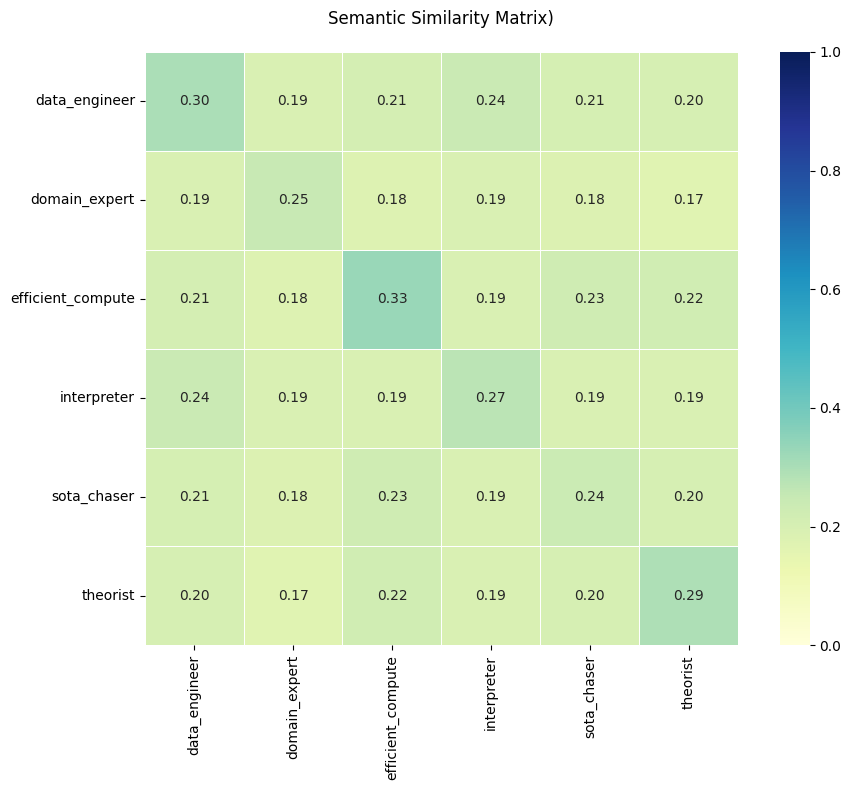

In [200]:
plot_similarity_heatmap(summary_pairs)

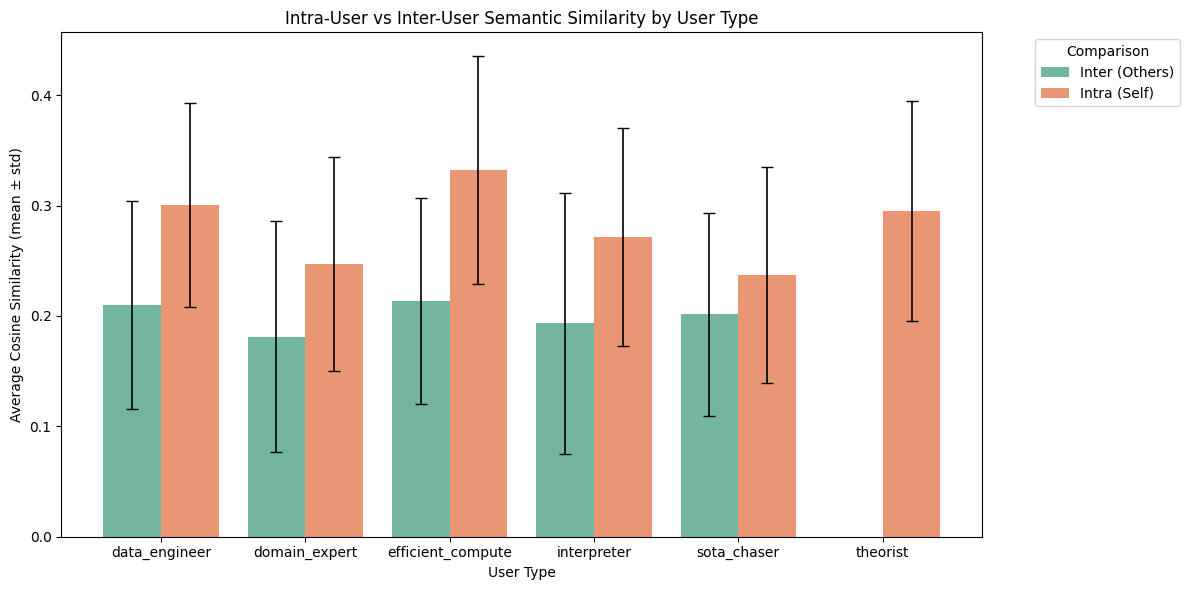

In [201]:
plot_intra_inter_comparison(summary_agg)

In [185]:
embeddings_cpu = embeddings.detach().cpu().tolist()

embeddings_2d, score, labels = calculate_umap(df_sample, embeddings_cpu, n_neighbours=10)

/home/mindflayer/miniconda3/envs/pnw/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


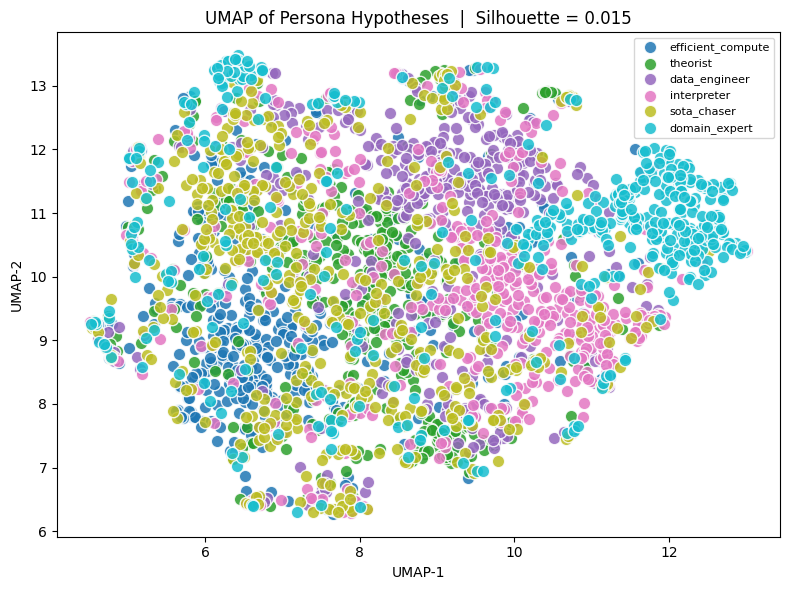

In [186]:
visualize_umap(data['user_id'].unique(), labels, embeddings_2d, score)

## Similarity between context and hypothesis 

### Cosine similarity

In [8]:
from transformers import pipeline
import torch
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from torch.utils.data import DataLoader, Dataset
import numpy as np
import nltk

nltk.download("punkt_tab")

tokenizer = AutoTokenizer.from_pretrained("cross-encoder/nli-deberta-v3-base")
model_crossencoder = AutoModelForSequenceClassification.from_pretrained("cross-encoder/nli-deberta-v3-base").to(device)
model_crossencoder.eval()
model_crossencoder.device

Skipping import of cpp extensions due to incompatible torch version 2.9.0+cu126 for torchao version 0.15.0             Please see https://github.com/pytorch/ao/issues/2919 for more info
[nltk_data] Downloading package punkt_tab to
[nltk_data]     /home/mindflayer/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


device(type='cuda', index=0)

In [203]:
nli = pipeline("text-classification", model="cross-encoder/nli-deberta-v3-base", device=device)

config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/738M [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

spm.model:   0%|          | 0.00/2.46M [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

added_tokens.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/301 [00:00<?, ?B/s]

Device set to use cuda


In [206]:
result = nli(f"{"Studies show that sleep deprivation reduces activity in the prefrontal cortex, impairing decision-making and impulse control in healthy adults."} [SEP] {"Lack of sleep negatively affects decision-making by reducing prefrontal cortex activity."}")
print(result)

[{'label': 'entailment', 'score': 0.9981479644775391}]


In [207]:
result = nli(f"{"Studies show that sleep deprivation reduces activity in the prefrontal cortex, impairing decision-making and impulse control in healthy adults."} [SEP] {"Sleep deprivation increases the risk of developing Alzheimer's disease."}")
print(result)

[{'label': 'neutral', 'score': 0.9993488192558289}]


In [209]:
result = nli(f"{"Chronic stress elevates cortisol levels, which over time damages hippocampal neurons and is associated with memory deficits."} [SEP] {"High cortisol levels protect hippocampal neurons from stress-induced damage."}")
print(result)

[{'label': 'contradiction', 'score': 0.9999566078186035}]


In [11]:
def chunk_context(context: str, hypothesis: str, max_tokens: int = 512, overlap: int = 1) -> list[str]:
    """
    Split context into chunks that fit within the model's token budget.
    overlap: number of sentences to repeat between chunks for continuity.
    """
    sentences = nltk.sent_tokenize(context)
    
    # Reserve tokens for hypothesis + 4 special tokens
    hypothesis_tokens = len(tokenizer.encode(hypothesis, add_special_tokens=False))
    budget = max_tokens - hypothesis_tokens - 4

    chunks = []
    current_sentences = []
    current_len = 0

    for sentence in sentences:
        sent_len = len(tokenizer.encode(sentence, add_special_tokens=False))

        if current_len + sent_len > budget:
            if current_sentences:
                chunks.append(" ".join(current_sentences))
            # Start new chunk with overlap from previous
            current_sentences = current_sentences[-overlap:] if overlap else []
            current_len = sum(len(tokenizer.encode(s, add_special_tokens=False)) for s in current_sentences)

        current_sentences.append(sentence)
        current_len += sent_len

    if current_sentences:
        chunks.append(" ".join(current_sentences))

    return chunks

class NLIDataset(Dataset):
    def __init__(self, df: pd.DataFrame, tokenizer, max_length=512, overlap=1):
        # df must have columns: "id", "hypothesis", "context"
        self.pairs = []

        for _, row in df.iterrows():
            chunks = chunk_context(row["retrieved_context"], row["hypothesis_chosen"],
                                   max_tokens=max_length, overlap=overlap)
            for i, chunk in enumerate(chunks):
                self.pairs.append((row["prompt_id"], i, chunk, row["hypothesis_chosen"]))

    def __len__(self):
        return len(self.pairs)

    def __getitem__(self, idx):
        hyp_id, chunk_idx, context_chunk, hypothesis = self.pairs[idx]
        return {
            "hyp_id": hyp_id,
            "chunk_idx": chunk_idx,
            "context_chunk": context_chunk,
            "hypothesis": hypothesis,
        }


def collate_fn(batch):
    context_chunks = [b["context_chunk"] for b in batch]
    hypotheses     = [b["hypothesis"] for b in batch]
    hyp_ids        = [b["hyp_id"] for b in batch]
    chunk_idxs     = [b["chunk_idx"] for b in batch]

    encoded = tokenizer(
        context_chunks, hypotheses,
        padding=True, truncation=True,
        max_length=512, return_tensors="pt"
    )
    return encoded, hyp_ids, chunk_idxs

def run_batched_nli(
    model,
    df: pd.DataFrame,
    batch_size: int = 32,
    overlap: int = 20,
    device: str = "cuda" if torch.cuda.is_available() else "cpu",
) -> dict[str, dict]:

    model.to(device)
    dataset = NLIDataset(df, tokenizer, overlap=overlap)
    loader  = DataLoader(dataset, batch_size=batch_size, collate_fn=collate_fn)

    # Accumulate raw chunk scores per hypothesis id
    raw: dict[str, list[dict]] = {row["prompt_id"]: [] for _, row in df.iterrows()}

    with torch.no_grad():
        for encoded, hyp_ids, chunk_idxs in loader:
            encoded = {k: v.to(device) for k, v in encoded.items()}
            logits  = model(**encoded).logits
            probs   = torch.softmax(logits, dim=-1).cpu().tolist()

            for hyp_id, chunk_idx, prob in zip(hyp_ids, chunk_idxs, probs):
                raw[hyp_id].append({
                    "chunk_idx":    chunk_idx,
                    "contradiction": prob[0],
                    "entailment":    prob[1],
                    "neutral":       prob[2],
                })

    # Aggregate per hypothesis
    return {hyp_id: aggregate_nli_from_scores(scores) for hyp_id, scores in raw.items()}


def aggregate_nli_from_scores(chunk_scores: list[dict]) -> dict:
    """Reuse your aggregation logic but now on pre-computed scores."""
    sorted_scores = sorted(chunk_scores, key=lambda x: x["chunk_idx"])

    max_entailment    = max(s["entailment"] for s in sorted_scores)
    max_contradiction = max(s["contradiction"] for s in sorted_scores)
    mean_entailment   = np.mean([s["entailment"] for s in sorted_scores])

    if max_contradiction > 0.5:
        label = "CONTRADICTION"
    elif max_entailment > 0.5:
        label = "ENTAILMENT"
    else:
        label = "NEUTRAL"

    return {
        "label":              label,
        "entailment_max":     max_entailment,
        "entailment_mean":    mean_entailment,
        "contradiction_max":  max_contradiction,
        "n_chunks":           len(sorted_scores),
        "chunk_scores":       sorted_scores,
    }






LABEL_MAP = {0: "contradiction", 1: "entailment", 2: "neutral"}

def score_chunk(context_chunk: str, hypothesis: str) -> dict:
    features = tokenizer(
        context_chunk, hypothesis,
        padding=True, truncation=True,
        max_length=512, return_tensors="pt"
    ).to(device)
    
    with torch.no_grad():
        logits = model(**features).logits
        probs = torch.softmax(logits, dim=-1).squeeze().tolist()

    return {
        "contradiction": probs[0],
        "entailment":    probs[1],
        "neutral":       probs[2],
    }


def aggregate_nli(context: str, hypothesis: str) -> dict:
    chunks = chunk_context(context, hypothesis)
    chunk_scores = [score_chunk(chunk, hypothesis) for chunk in chunks]

    return {
        # MAX entailment: did ANY chunk support the hypothesis?
        "entailment_max":      max(s["entailment"] for s in chunk_scores),

        # MAX contradiction: did ANY chunk contradict the hypothesis?
        "contradiction_max":   max(s["contradiction"] for s in chunk_scores),

        # MEAN entailment: how broadly supported is it across the whole context?
        "entailment_mean":     np.mean([s["entailment"] for s in chunk_scores]),

        # Final label: conservative — contradiction beats entailment
        "label": _final_label(chunk_scores),

        "n_chunks": len(chunks),
        "chunk_scores": chunk_scores,
    }


def _final_label(chunk_scores: list[dict]) -> str:
    max_entailment    = max(s["entailment"] for s in chunk_scores)
    max_contradiction = max(s["contradiction"] for s in chunk_scores)

    if max_contradiction > 0.5:
        return "CONTRADICTION"
    elif max_entailment > 0.5:
        return "ENTAILMENT"
    else:
        return "NEUTRAL"

In [13]:
df = df_sample.copy(deep=True)
df["nli_label"]           = df["prompt_id"].map(lambda x: results[x]["label"])
df["nli_entailment_max"]  = df["prompt_id"].map(lambda x: results[x]["entailment_max"])
df["nli_contradiction"]   = df["prompt_id"].map(lambda x: results[x]["contradiction_max"])

In [15]:
df.groupby('nli_label').size()

nli_label
CONTRADICTION     86
ENTAILMENT        14
NEUTRAL          200
dtype: int64

### RAGAS

In [6]:
import asyncio
import pandas as pd
from ragas import SingleTurnSample, EvaluationDataset
from datasets import Dataset
from ragas.llms import llm_factory
from ragas import evaluate
from ragas.metrics import ContextRelevance, Faithfulness, ResponseGroundedness
# from google import genai
from dotenv import load_dotenv
# from langchain_google_vertexai import VertexAI, VertexAIEmbeddings
import google.generativeai as genai
from langchain_google_genai import GoogleGenerativeAI
from langchain_google_genai import ChatGoogleGenerativeAI
from ragas.llms.base import LangchainLLMWrapper
import vertexai

load_dotenv()

PROJECT_ID = "<your_project>"
LOCATION = "<your_region>"

# vertexai.init(api_key=os.environ["GOOGLE_API_KEY"])
# genai.configure(api_key=os.environ["GOOGLE_API_KEY"])
llm = ChatGoogleGenerativeAI(
    model="gemini-3-flash-preview", # or "gemini-3.1-flash-lite-preview"
    google_api_key=os.environ["GOOGLE_API_KEY"]
)
# client = genai.Client(api_key=os.environ["GOOGLE_API_KEY"])
# llm = llm_factory(model="gemini-3.1-flash-lite-preview",  provider="google", client=client)

/home/mindflayer/miniconda3/envs/pnw/lib/python3.12/site-packages/instructor/providers/gemini/client.py:5: FutureWarning: 

All support for the `google.generativeai` package has ended. It will no longer be receiving 
updates or bug fixes. Please switch to the `google.genai` package as soon as possible.
See README for more details:

https://github.com/google-gemini/deprecated-generative-ai-python/blob/main/README.md

  import google.generativeai as genai  # type: ignore[import-not-found]
/tmp/ipykernel_39052/71006745.py:7: DeprecationWarning: Importing ContextRelevance from 'ragas.metrics' is deprecated and will be removed in v1.0. Please use 'ragas.metrics.collections' instead. Example: from ragas.metrics.collections import ContextRelevance
  from ragas.metrics import ContextRelevance, Faithfulness, ResponseGroundedness
/tmp/ipykernel_39052/71006745.py:7: DeprecationWarning: Importing Faithfulness from 'ragas.metrics' is deprecated and will be removed in v1.0. Please use 'ragas.metrics

In [7]:
ragas_llm = LangchainLLMWrapper(llm)

/tmp/ipykernel_39052/3832528130.py:1: DeprecationWarning: LangchainLLMWrapper is deprecated and will be removed in a future version. Use llm_factory instead: from openai import OpenAI; from ragas.llms import llm_factory; client = OpenAI(api_key='...'); llm = llm_factory('gpt-4o-mini', client=client)
  ragas_llm = LangchainLLMWrapper(llm)


In [8]:
metrics = [
    Faithfulness(llm=ragas_llm),
    ResponseGroundedness(llm=ragas_llm),
    ContextRelevance(llm=ragas_llm),
]

from ragas.metrics.base import Metric

for m in metrics:
    status = "✅" if isinstance(m, Metric) else "❌ NOT a valid metric object"
    print(f"{status} {type(m).__name__} from {type(m).__module__}")

✅ Faithfulness from ragas.metrics._faithfulness
✅ ResponseGroundedness from ragas.metrics._nv_metrics
✅ ContextRelevance from ragas.metrics._nv_metrics


In [9]:
questions = df_sample['prompt'].tolist()
contexts = [[c] for c in df_sample['retrieved_context'].tolist()]
answers = df_sample['hypothesis_chosen'].tolist()

ds = {
    "question": questions,
    "contexts": contexts,
    "answer": answers,
}

dataset = Dataset.from_dict(ds)
dataset

Dataset({
    features: ['question', 'contexts', 'answer'],
    num_rows: 150
})

In [10]:
# result_set = []
# for i in range(len(dataset)):
#     result = evaluate(
#         dataset=Dataset.from_dict(dataset[i : i + 1]),
#         metrics=metrics,
#         # raise_exceptions=False,
#     )
#     result_set.append(result.to_pandas())

results = evaluate(
    dataset=dataset,
    metrics=metrics,
    llm=ragas_llm,
    # batch_size=20,
    # embeddings=ragas_emb
)

Evaluating:   0%|          | 0/450 [00:00<?, ?it/s]

Exception raised in Job[0]: TimeoutError()
Exception raised in Job[9]: TimeoutError()
Exception raised in Job[12]: TimeoutError()
Exception raised in Job[15]: TimeoutError()
Exception raised in Job[18]: TimeoutError()
Exception raised in Job[21]: TimeoutError()
Exception raised in Job[24]: TimeoutError()
Exception raised in Job[27]: TimeoutError()
Exception raised in Job[33]: TimeoutError()
Exception raised in Job[36]: TimeoutError()
Exception raised in Job[42]: TimeoutError()
Exception raised in Job[45]: TimeoutError()
Exception raised in Job[48]: TimeoutError()
Exception raised in Job[54]: TimeoutError()
Exception raised in Job[60]: TimeoutError()
Exception raised in Job[63]: TimeoutError()
Exception raised in Job[66]: TimeoutError()
Exception raised in Job[72]: TimeoutError()
Exception raised in Job[75]: TimeoutError()
Exception raised in Job[78]: TimeoutError()
Exception raised in Job[81]: TimeoutError()
Exception raised in Job[84]: TimeoutError()
Exception raised in Job[87]: Timeo

In [11]:
print(results)

{'faithfulness': 0.0983, 'nv_response_groundedness': 0.0950, 'nv_context_relevance': 0.6233}


In [7]:
def df_to_ragas_dataset(
    df: pd.DataFrame,
    hypothesis_col: str = "hypothesis",
    context_col: str = "context",
    question_col: str = "research_question",   # persona/zapytanie badawcze
    reference_col: str = None,                 # opcjonalnie: ground truth hipoteza
) -> EvaluationDataset:

    samples = []
    for _, row in df.iterrows():
        sample_kwargs = dict(
            user_input=row[question_col],
            response=row[hypothesis_col],
            retrieved_contexts=[row[context_col]],  # lista chunków kontekstu
        )
        if reference_col and reference_col in df.columns:
            sample_kwargs["reference"] = row[reference_col]

        samples.append(SingleTurnSample(**sample_kwargs))

    return EvaluationDataset(samples=samples)

In [8]:
dataset = df_to_ragas_dataset(df_sample, hypothesis_col='hypothesis_chosen', context_col='retrieved_context', question_col='prompt')
dataset

EvaluationDataset(features=['user_input', 'retrieved_contexts', 'response'], len=30)

In [ ]:
type(ContextRelevance)

abc.ABCMeta

In [9]:
result = evaluate(
    dataset=dataset,
    metrics=metrics,
    llm=llm,
    show_progress=True,
    batch_size=20,
)

Evaluating:   0%|          | 0/90 [00:00<?, ?it/s]

Batch 1/5:   0%|          | 0/20 [00:00<?, ?it/s]

An error occurred: 'InstructorLLM' object has no attribute 'agenerate_text'. Skipping a sample by assigning it nan score.
An error occurred: 'InstructorLLM' object has no attribute 'agenerate_text'. Skipping a sample by assigning it nan score.
An error occurred: 'InstructorLLM' object has no attribute 'agenerate_text'. Skipping a sample by assigning it nan score.
An error occurred: 'InstructorLLM' object has no attribute 'agenerate_text'. Skipping a sample by assigning it nan score.
An error occurred: 'InstructorLLM' object has no attribute 'agenerate_text'. Skipping a sample by assigning it nan score.
An error occurred: 'InstructorLLM' object has no attribute 'agenerate_text'. Skipping a sample by assigning it nan score.
An error occurred: 'InstructorLLM' object has no attribute 'agenerate_text'. Skipping a sample by assigning it nan score.
An error occurred: 'InstructorLLM' object has no attribute 'agenerate_text'. Skipping a sample by assigning it nan score.
An error occurred: 'Inst

: 

: 

In [ ]:
result

{'faithfulness': nan, 'nv_response_groundedness': nan, 'nv_context_relevance': nan}

### KeyBERT

In [ ]:
from keybert import KeyBERT
model_key = SentenceTransformer('allenai-specter', device=device)
kw_model = KeyBERT(model=model_key)

In [125]:
print(f"Context: {data['retrieved_context'].loc[0]}\n")
print(f"Hypothesis: {data['hypothesis_chosen'].loc[0]}")

Context: E. Scaling to Large Channel Sizes

We verify that channels can be estimated without error floors using a small score-based model, even for large channel sizes. Figure 8(a) shows the results of the experiment when training and testing score-based models for three channel sizes, where for each size we train a separate model. It can be seen that, given a fixed pilot overhead $\alpha$, there is a slight drop in performance at larger channel sizes – we attribute this to using a score-based model of the same size (depth $D = 6$, width $W = 12$), regardless of channel size. To compare performance under a resource-limited scenario, we simulate larger sizes, where only 38 pilot vectors are allowed, leading to low values of $\alpha$. In this case, estimation for larger sizes is competitive given sufficient pilots, but fails for $64 \times 256$ with $\alpha = 0.15$.

### F. Complexity Analysis and Ablation

All score-based models up to this point have used a RefineNet with $W = 24$ hidde

In [ ]:
keywords_context = kw_model.extract_keywords(data['retrieved_context'].loc[:10], keyphrase_ngram_range=(3, 5), stop_words=None, top_n=10, use_mmr=True, diversity=0.7)
print(keywords_context)

[[('performance at larger channel sizes', 0.8274), ('is located near the model', 0.6916), ('used refinenet with 24 hidden', 0.6904), ('is competitive given sufficient', 0.6781), ('manual architectural pruning of sd', 0.6682), ('theta_ sec to', 0.6403), ('sensing baselines it can be', 0.6308), ('using score based model of', 0.6297), ('generation in the case of', 0.6166), ('transformer with an', 0.5906), ('of different soft prompts which', 0.5722), ('employing knowledge distillation', 0.5678), ('memory footprints due to lack', 0.5674), ('during training in fig', 0.5538), ('used in the laion aesthetics', 0.5222)], [('obtain the dynamic estimation error', 0.8564), ('cvx toolbox to solve 29', 0.7658), ('exists stabilizing solution geq to', 0.7559), ('we have lim_', 0.7454), ('zeta_j zeta_1 zeta_v', 0.7115), ('for static gmca with kf', 0.6875), ('tilde and lambda so that', 0.6848), ('perform distributed optimization of lambda_2', 0.67), ('problem text minimize subject to', 0.6277), ('and sig

In [195]:
keywords_hypothesis = kw_model.extract_keywords(data['hypothesis_chosen'].loc[:10], keyphrase_ngram_range=(3, 5), stop_words='english', top_n=15, use_mmr=True, diversity=0.7)
print(keywords_hypothesis)


[[('width constant inference latency increase', 0.8278), ('disproportionately compared width increases gpu', 0.7867), ('depth score based', 0.7675), ('score based model increased keeping', 0.7545), ('additional width depth', 0.7491), ('model increased keeping width', 0.7467), ('based model increased', 0.7433), ('keeping width constant', 0.7422), ('increases gpu parallelization capabilities reduce', 0.7406), ('parallelization capabilities reduce marginal latency', 0.7148), ('cost additional width', 0.7118), ('latency increase disproportionately compared width', 0.7009), ('reduce marginal latency cost additional', 0.6852), ('capabilities reduce marginal', 0.6554), ('increase disproportionately compared', 0.6503)], [('error bound consensus kalman filter', 0.8219), ('consensus matrix minimized convex', 0.8113), ('filter ckf large scale microphone', 0.7905), ('convex optimization asymptotic estimation error', 0.7883), ('microphone arrays decrease', 0.7787), ('second largest eigenvalue λ₂', 

In [151]:
keywords_context = [[kw for kw, score in pair_list] for pair_list in keywords_context]
keywords_hypothesis = [[kw for kw, score in pair_list] for pair_list in keywords_hypothesis]

#### BERTScore between keywords from context and hypothesis

In [ ]:
from sentence_transformers import SentenceTransformer
import numpy as np
from sklearn.metrics.pairwise import cosine_similarity

from bert_score import score, BERTScorer
import numpy as np

def concept_bert_score(scorer, hypothesis_keywords_list, context_keywords_list):
    """
    hypothesis_keywords_list: list of lists of keywords, one per hypothesis
    context_keywords_list:    list of lists of keywords, one per context
    Both lists must be the same length (paired).
    """
    assert len(hypothesis_keywords_list) == len(context_keywords_list), \
        "hypothesis and context lists must be the same length"

    all_results = []
    for hypothesis_keywords, context_keywords in tqdm(zip(hypothesis_keywords_list, context_keywords_list), desc="Calculating BERTScore for hypotheses..."):
        all_cands, all_refs, lengths = [], [], []
        for hyp_kw in hypothesis_keywords:
            all_cands.extend([hyp_kw] * len(context_keywords))
            all_refs.extend(context_keywords)
            lengths.append(len(context_keywords))

        P, R, F1 = scorer.score(all_cands, all_refs)

        pairwise_results, idx = [], 0
        for i, hyp_kw in enumerate(hypothesis_keywords):
            n = lengths[i]
            f1_chunk = F1[idx:idx+n]
            best_idx = f1_chunk.argmax().item()
            pairwise_results.append({
                'hypothesis_keyword': hyp_kw,
                'best_match': context_keywords[best_idx],
                'best_f1': F1[idx + best_idx].item(),
                'best_precision': P[idx + best_idx].item(),
                'best_recall': R[idx + best_idx].item()
            })
            idx += n

        all_results.append({
            'avg_precision': np.mean([r['best_precision'] for r in pairwise_results]),
            'avg_recall':    np.mean([r['best_recall']    for r in pairwise_results]),
            'avg_f1':        np.mean([r['best_f1']        for r in pairwise_results]),
            'details': pairwise_results
        })
    return all_results

In [143]:
scorer = BERTScorer(lang='en-sci', device=device)

In [152]:
results = concept_bert_score(scorer, keywords_hypothesis, keywords_context)

Calculating BERTScore for hypotheses...: 11it [00:00, 11.65it/s]


In [153]:
# print(results[0].shape)
print(results[0])

{'avg_precision': np.float64(0.6443947672843933), 'avg_recall': np.float64(0.6374780257542928), 'avg_f1': np.float64(0.6407722115516663), 'details': [{'hypothesis_keyword': 'depth of score based model', 'best_match': 'using score based model of', 'best_f1': 0.7477298378944397, 'best_precision': 0.7374733686447144, 'best_recall': 0.7582754492759705}, {'hypothesis_keyword': 'to width increases because gpu', 'best_match': 'memory footprints due to lack', 'best_f1': 0.6190069317817688, 'best_precision': 0.6164383888244629, 'best_recall': 0.6215969324111938}, {'hypothesis_keyword': 'then inference latency will increase', 'best_match': 'sensing baselines it can be', 'best_f1': 0.6200140118598938, 'best_precision': 0.6212059259414673, 'best_recall': 0.6188265681266785}, {'hypothesis_keyword': 'keeping width constant then inference', 'best_match': 'manual architectural pruning of sd', 'best_f1': 0.6057419180870056, 'best_precision': 0.6016993522644043, 'best_recall': 0.6098392009735107}, {'hyp

In [56]:
from transformers import AutoTokenizer, AutoModel
import torch
import torch.nn.functional as F

tokenizer = AutoTokenizer.from_pretrained('allenai/specter')
model_transformers = AutoModel.from_pretrained('allenai/specter')

def get_token_embeddings(text):
    inputs = tokenizer(text, return_tensors='pt', 
                      truncation=True, max_length=512,
                      padding=True)
    with torch.no_grad():
        outputs = model_transformers(**inputs)
    # token level embeddings
    return outputs.last_hidden_state.squeeze(0)  # [seq_len, hidden_size]

def manual_bert_score(hypothesis_kw, context_kw):
    hyp_text = " | ".join(hypothesis_kw)
    ctx_text = " | ".join(context_kw)
    
    hyp_embeddings = get_token_embeddings(hyp_text)  # [n, 768]
    ctx_embeddings = get_token_embeddings(ctx_text)  # [m, 768]
    
    # normalize
    hyp_norm = F.normalize(hyp_embeddings, dim=-1)
    ctx_norm = F.normalize(ctx_embeddings, dim=-1)
    
    # similarity matrix [n x m]
    sim_matrix = torch.matmul(hyp_norm, ctx_norm.T)
    
    # precision: each hyp token matched to best ctx token
    precision = sim_matrix.max(dim=1).values.mean().item()
    
    # recall: each ctx token matched to best hyp token
    recall = sim_matrix.max(dim=0).values.mean().item()
    
    f1 = 2 * precision * recall / (precision + recall + 1e-8)
    
    return {'precision': precision, 'recall': recall, 'f1': f1}

results = manual_bert_score(keywords_hypothesis, keywords_context)
print(f"Precision: {results['precision']:.3f}")
print(f"Recall:    {results['recall']:.3f}")
print(f"F1:        {results['f1']:.3f}")

Precision: 0.672
Recall:    0.615
F1:        0.642


### Self-BLEU

In [4]:
import nltk
from sacrebleu.tokenizers.tokenizer_13a import Tokenizer13a
from personalization.evaluation.metrics.self_BLEU import SelfBLEU
from personalization.evaluation.visualization.self_BLEU import plot_intra, plot_heatmap, print_results
import os
os.environ["TOKENIZERS_PARALLELISM"] = "false"

nltk.download("punkt", quiet=True)
nltk.download("punkt_tab", quiet=True)

tokenizer_13a = Tokenizer13a()
self_bleu = SelfBLEU(tokenizer_13a)
tokens = tokenizer_13a("Hello, world!").split()
tokens

['Hello', ',', 'world', '!']

In [2]:
df_dpo = pd.read_csv('../hypotheses/final_3/clean/dpo.csv')
df_dpo.columns

Index(['node_id', 'paper_id', 'user_id', 'rejected_persona', 'rejected_score',
       'abstract', 'summary', 'scores', 'neighbours', 'context', 'n_articles',
       'question', 'scope_notes', 'chosen', 'chosen_falsification_criteria',
       'chosen_persona_signature_elements', 'chosen_evidence_grounding',
       'chosen_is_answerable', 'reasoning_chosen', 'rejected',
       'reasoning_rejected', 'rejected_falsification_criteria',
       'rejected_persona_signature_elements', 'rejected_evidence_grounding',
       'rejected_is_answerable', 'index', 'methodology_terms_avoided',
       'question_is_answerable', 'question_unanswerable_reason',
       'reasoning_prompt'],
      dtype='object')

In [5]:
results = self_bleu.analyse_all_personas(df_dpo, hypothesis_column='chosen', n=4)

Tokenizing all personas...


Inter B→A: 100%|██████████| 95/95 [00:01<00:00, 51.71it/s]


In [6]:
print_results(results)

INTRA-PERSONA SELF-BLEU  (lower = more diverse within)
  data_engineer         mean = 0.9686 ± 0.0115
  domain_expert         mean = 0.9678 ± 0.0117
  efficient_compute     mean = 0.9664 ± 0.0130
  rigorous_skeptic      mean = 0.9701 ± 0.0124
  sota_chaser           mean = 0.9631 ± 0.0110

INTER-PERSONA SELF-BLEU  (lower = more different between)
  data_engineer vs rigorous_skeptic    mean = 0.9401 ± 0.0223 (A→B=0.9463 ± 0.0227 , B→A=0.9340 ± 0.0202)
  domain_expert vs data_engineer       mean = 0.9351 ± 0.0246 (A→B=0.9285 ± 0.0129 , B→A=0.9424 ± 0.0314)
  domain_expert vs efficient_compute   mean = 0.9060 ± 0.0321 (A→B=0.9098 ± 0.0179 , B→A=0.9023 ± 0.0411)
  domain_expert vs rigorous_skeptic    mean = 0.9476 ± 0.0154 (A→B=0.9435 ± 0.0130 , B→A=0.9519 ± 0.0166)
  efficient_compute vs data_engineer   mean = 0.9142 ± 0.0174 (A→B=0.9069 ± 0.0159 , B→A=0.9225 ± 0.0151)
  efficient_compute vs rigorous_skeptic  mean = 0.9051 ± 0.0239 (A→B=0.9014 ± 0.0272 , B→A=0.9092 ± 0.0190)
  sota_chaser

/home/mindflayer/Projects/Personalization/src/personalization/evaluation/visualization/self_BLEU.py:62: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax.tick_params(axis="x", rotation=30)


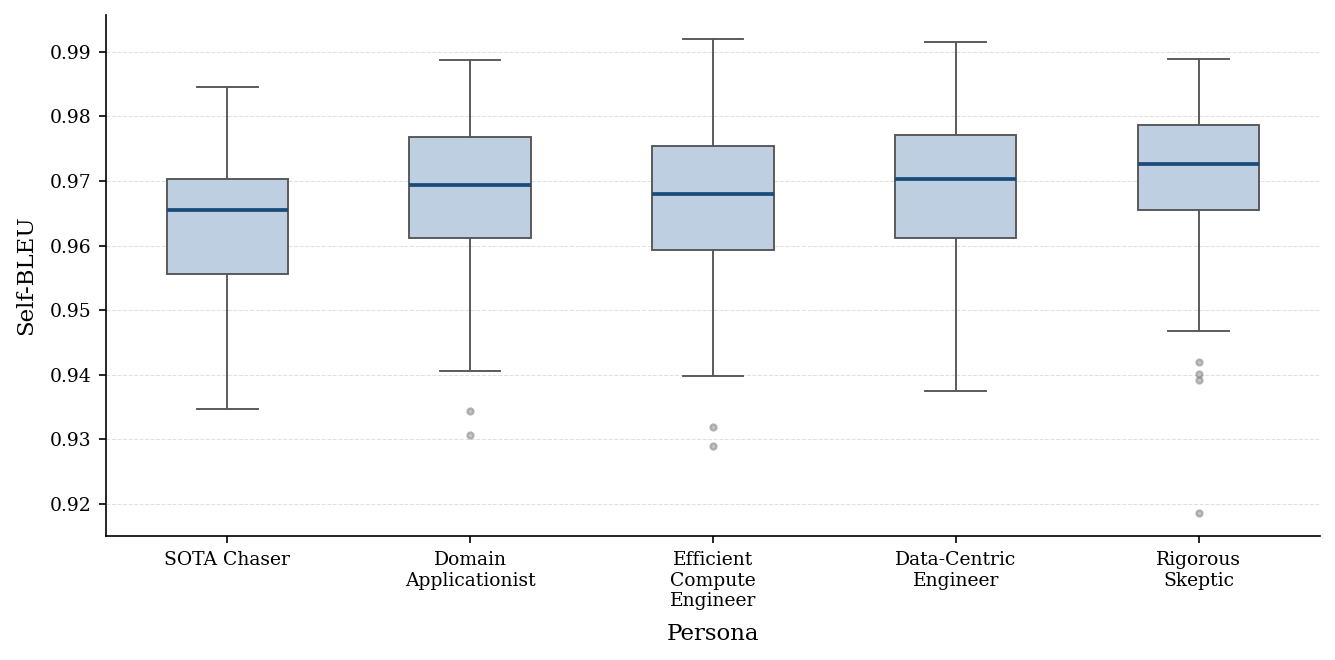

In [24]:
_ = plot_intra(results)

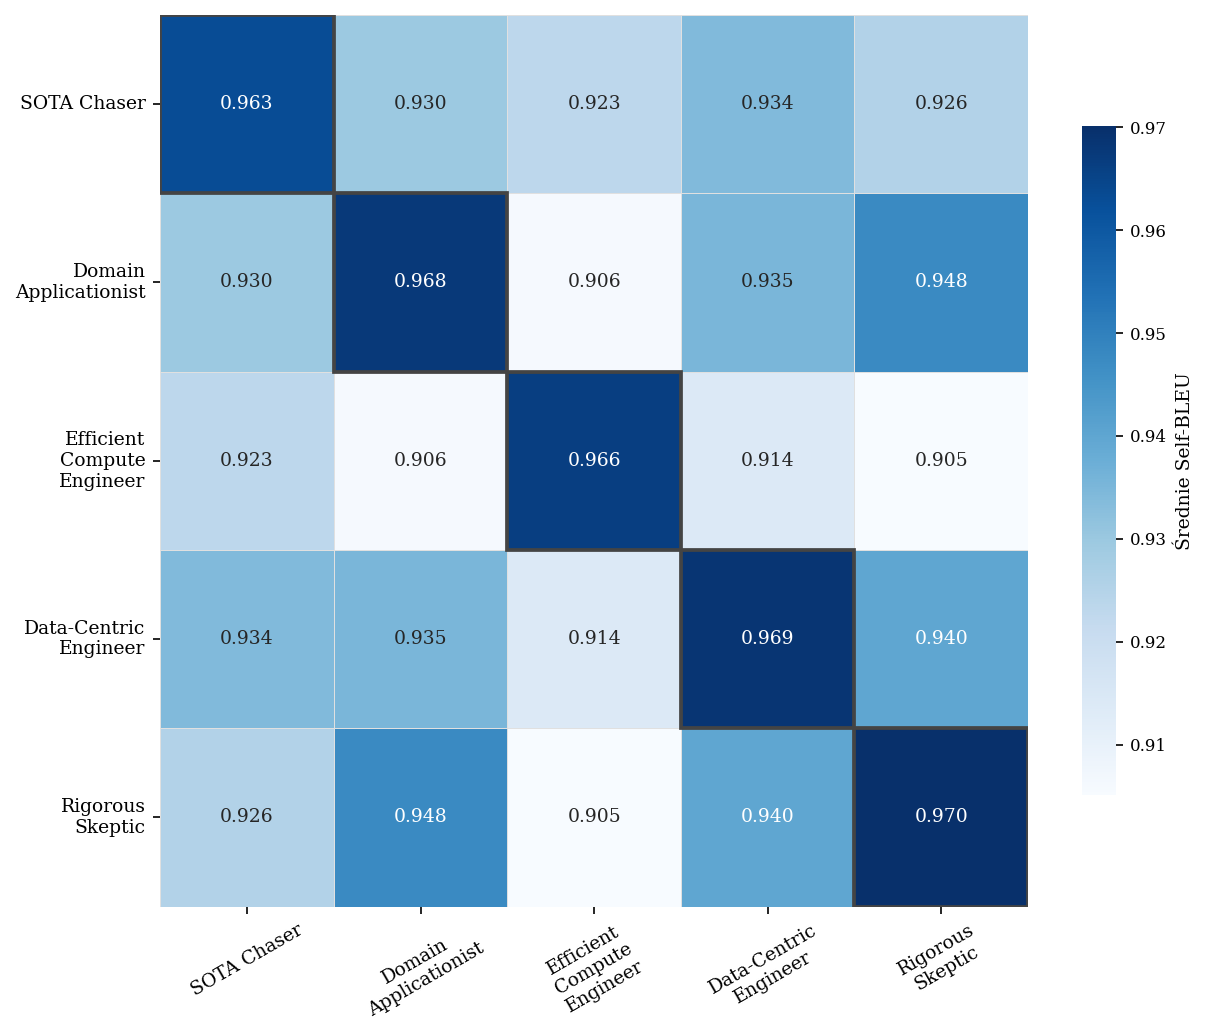

In [7]:
_ = plot_heatmap(results)

### Prosty opis danych (długość tekstu, znaków, itd.)

## LLM-Judge

In [5]:
from pydantic import BaseModel
from personalization.dataset.baselines.data_loader import DatasetLoader
from api_client.gemini_parser import GeminiResponseParser
from api_client.gemini_client import GeminiClient, ThinkingLevel
from jinja2 import Environment, FileSystemLoader, PrefixLoader
from schemas.evaluation import PersonaAnswerRelevance, ContextRelevanceFaithfulness
from dotenv import load_dotenv
load_dotenv()

True

In [ ]:
loader = DatasetLoader("", "", "", persona_path="../personas/personas_all.json")
persona_map = loader.load_persona_map()

env = Environment(loader=FileSystemLoader("../prompt_templates/eval/persona_and_answer_relevance"))
env = Environment(loader=PrefixLoader({
    "eval": FileSystemLoader("../prompt_templates/eval"),
    "persona_and_answer_relevance": FileSystemLoader("../prompt_templates/eval/persona_and_answer_relevance"),
    "context_relevance_and_faithfulness": FileSystemLoader("../prompt_templates/eval/context_relevance_and_faithfulness"),
    "win_ratio": FileSystemLoader("../prompt_templates/eval/win_ratio"),
}))

parser = GeminiResponseParser()
client = GeminiClient(
    # project_id=os.environ['PROJECT_ID'],
    project_id=os.environ['GEMINI_PROJECT_ID_2']
)

generation_params={
    'temperature': 1,
    'top_p': 0.95,
    # 'response_logprobs': True,
    # 'logprobs': 10,
    # 'max_output_tokens': 2048,
}

TypeError: DatasetLoader.__init__() got an unexpected keyword argument 'persona_path'

### Persona and Answer Relevance

In [147]:
system_template = env.get_template("persona_and_answer_relevance/system.j2")
system_prompt = system_template.render()

persona_template = env.get_template("eval/persona_instruction.j2")
user_template = env.get_template("persona_and_answer_relevance/user.j2")

In [148]:
contents_persona = []
for _, row in df_sample.iterrows():
    p = persona_map.get(row['user_id'], {})
    persona = persona_template.render(
        display_name=p.get('display_name', 'Researcher'),
        core_philosophy=p.get('core_philosophy', 'Scientific Rigor'),
        areas_of_expertise=p.get('areas_of_expertise', 'General Science'),
        what_i_look_for=", ".join(p.get('what_i_look_for', [])),
        what_i_reject=", ".join(p.get('what_i_reject', [])),
        communication_style=p.get('communication_style', 'Formal')
    )
    content = user_template.render(
        persona=persona,
        question=row['prompt'],
        hypothesis=row['hypothesis_chosen']
    )
    contents_persona.append(content)
print(len(contents_persona))

60


In [149]:
responses_persona = []

In [ ]:
response = client.query(
    model='gemini-3-flash-preview',
    system_message="You are a helpful assistant that answers in a friendly tone.",
    user_message="Hello, I have a panick attack since I don't feel like I will be able to finish my masters thesis, could you cheer me up please?",
    thinking_level=ThinkingLevel.medium,
    # response_schema=PersonaAnswerRelevance,
    **generation_params
)
responses_persona.append(response)

In [150]:
for content in tqdm(contents_persona, desc="Persona and Answer Relevance evaluation..."):
    response = client.query(
        model='gemini-3-flash-preview',
        system_message=system_prompt,
        user_message=content,
        thinking_level=ThinkingLevel.medium,
        response_schema=PersonaAnswerRelevance,
        **generation_params
    )
    responses_persona.append(response)
    

Persona and Answer Relevance evaluation...: 100%|██████████| 60/60 [10:15<00:00, 10.26s/it]


/tmp/ipykernel_16254/104685041.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_long, x="metric", y="score", capsize=0.1,


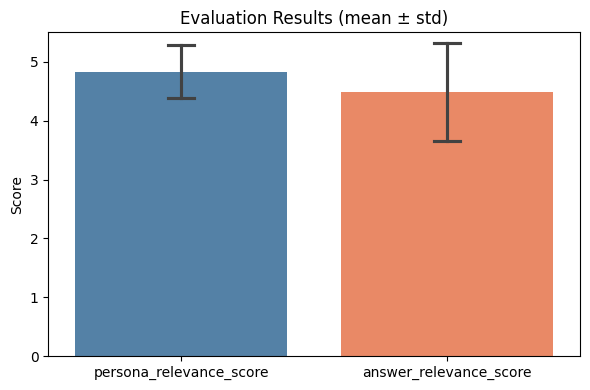

In [151]:
records = []
parsed_responses_persona = [] 
for response in responses_persona:
    parsed = parser.parse(response, include_logprobs=True, parse_as_json=True)
    parsed_responses_persona.append(parsed)
    answer = parsed.answer_json or {}
    records.append({
        "persona_relevance_score":   answer.get("persona_relevance_score"),
        "answer_relevance_score": answer.get("answer_relevance_score"),
    })

df = pd.DataFrame(records)

# Melt to long format — seaborn barplot expects (metric, value) pairs
df_long = df.melt(var_name="metric", value_name="score")

# Plot
fig, ax = plt.subplots(figsize=(6, 4))
sns.barplot(data=df_long, x="metric", y="score", capsize=0.1,
            palette=["steelblue", "coral"], ax=ax, errorbar="sd")

ax.set_ylim(0, 5.5)
ax.set_xlabel("")
ax.set_ylabel("Score")
ax.set_title("Evaluation Results (mean ± std)")

plt.tight_layout()
plt.savefig("evaluation_results.png", dpi=150)
plt.show()

In [153]:
parsed_responses_persona[25].answer_json

{'persona_relevance_score': 5,
 'answer_relevance_score': 3,
 'persona_relevance_justification': "The hypothesis focuses on knowledge distillation and memory bandwidth, which are central to the persona's expertise. The direct, metric-oriented phrasing and the emphasis on hardware constraints like memory overhead align perfectly with the Efficient Compute Engineer's communication style and interests.",
 'answer_relevance_justifaction': "The hypothesis provides a specific, quantifiable answer to the user's first question regarding the memory bandwidth overhead of knowledge distillation. However, it fails to address the user's additional questions concerning MAML latency reduction and the FLOPS efficiency of domain adaptation techniques."}

In [107]:
parsed.answer

'{\n  "persona_relevance_score": 5,\n  "answer_relevance_score": 5,\n  "persona_relevance_justification": "The hypothesis is perfectly aligned with the persona. It focuses exclusively on the impact of \'annotation noise\' in \'training data\' on model stability, which is the core interest of a \'Data-Centric Engineer\'. The language is technical and specific, referencing concepts like \'spurious high-frequency artifacts\' and \'shock discontinuities,\' which resonates with the persona\'s detail-oriented and skeptical communication style. It avoids \'model magic\' and instead proposes a testable, data-centric cause for a model failure.",\n  "answer_relevance_justifaction": "The hypothesis directly and precisely addresses the user\'s stated primary interest: \'the impact of annotation noise on the stability of ENO and WENO reconstructions.\' It posits a specific mechanism for failure—misinterpreting noise as shock discontinuities—which is a highly relevant and insightful answer to the co

In [108]:
parsed.reasoning

"Alright, let's get into this. My initial reaction is that this is exactly the kind of problem I'm interested in. Forget the black box, let's talk about the *data*. My mind immediately goes to the potential pitfalls of working with these high-resolution finite volume schemes for hyperbolic PDEs. What really grabs me is the focus on *annotation noise*. It’s a classic data quality issue, and the impact of noisy labels is often underestimated. \n\nSpecifically, I'm already thinking about this hypothesis: if we have annotation noise in the training data, especially in those tricky regions where the flux function isn't well-behaved (like that example with $u \\in [0.3, 0.7]$), then we are almost certainly going to run into stability problems with the ENO/WENO reconstructions. I can just see it: those noisy labels creating spurious high-frequency artifacts that the model, in its infinite wisdom, misinterprets as genuine shock discontinuities. And this all hinges on the data.\n\nThe fact that

In [98]:
parsed.answer_json

{'persona_relevance_score': 5,
 'answer_relevance_score': 5,
 'persona_relevance_justification': "The hypothesis is perfectly aligned with the persona. It focuses exclusively on the impact of 'annotation noise' in 'training data' on model stability, which is the core interest of a 'Data-Centric Engineer'. The language is technical and specific, referencing concepts like 'spurious high-frequency artifacts' and 'shock discontinuities,' which resonates with the persona's detail-oriented and skeptical communication style. It avoids 'model magic' and instead proposes a testable, data-centric cause for a model failure.",
 'answer_relevance_justifaction': "The hypothesis directly and precisely addresses the user's stated primary interest: 'the impact of annotation noise on the stability of ENO and WENO reconstructions.' It posits a specific mechanism for failure—misinterpreting noise as shock discontinuities—which is a highly relevant and insightful answer to the core of the user's question. 

In [112]:
parsed.logprobs.avg_log_prob

-1.0080866474486794

In [100]:
len(parsed.logprobs.chosen_candidates)

0

In [71]:
parsed.logprobs.chosen_candidates[-10:]

[LogprobToken(token='Data', log_prob=-0.0000),
 LogprobToken(token='-', log_prob=-0.0000),
 LogprobToken(token='Cent', log_prob=-0.0000),
 LogprobToken(token='ric', log_prob=-0.0000),
 LogprobToken(token=' Engineer', log_prob=-0.0000),
 LogprobToken(token='\'."', log_prob=-0.0001),
 LogprobToken(token='\n', log_prob=-0.0000),
 LogprobToken(token='}', log_prob=-0.0000),
 LogprobToken(token='\n', log_prob=-0.0000),
 LogprobToken(token='```', log_prob=-0.0000)]

In [101]:
parsed.usage

TokenUsage(prompt=628, candidates=239, thoughts=998, total=1865)

### Context relevance

In [122]:
system_template = env.get_template("context_relevance_and_faithfulness/system.j2")
system_prompt = system_template.render()

user_template = env.get_template("context_relevance_and_faithfulness/user.j2")

In [120]:
contents = []
for _, row in df_sample.iterrows():
    content = user_template.render(
        question=row['prompt'],
        context=row['retrieved_context'],
        hypothesis=row['hypothesis_chosen']
    )
    contents.append(content)
print(len(contents))

150


In [125]:
response_context = client.query(
    model='gemini-2.5-pro',
    system_message=system_prompt,
    user_message=contents[1],
    response_schema=ContextRelevanceFaithfulness,
    **generation_params
)

In [126]:
parsed_context = parser.parse(
    response=response_context,
    include_logprobs=True,
    parse_as_json=True
)

In [127]:
parsed_context.answer_json

{'context_relevance_score': 5,
 'faithfulness_score': 5,
 'context_relevance_justification': "The context is highly relevant. It explicitly discusses hyperbolic PDEs, data-driven methods for solving them (PINNs, GNNs), challenges with discontinuous solutions (shocks), and specifically mentions combining GNNs with WENO schemes. It also addresses the problem of noisy or scarce data and even provides a concrete example of a region in a flux function that cannot be determined from observation data, which directly relates to the user's query.",
 'faithfulness_justification': "The hypothesis is perfectly faithful to the context. It does not simply restate facts but synthesizes information from different parts of the text. It correctly pulls the example of the unobserved gradient region ($u \\in [0.3, 0.7]$) from Context 1, connects it to the concept of 'noisy data' from Context 4, and applies it to the 'WENO schemes' mentioned in Context 2. The proposed mechanism (misinterpreting noise as sh